In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'E:\Data analysis projects\cricket_odi_analytics\data\odi_ball_by_ball.csv')  
batting_stats = pd.read_csv(r'E:\Data analysis projects\cricket_odi_analytics\data\batting_stats.csv')  

#### Identify wicketkeeper dismissals (caught and stumped)

In [3]:
keepers_with_stumpings = df[
    (df['wicket_kind'] == 'stumped') & 
    (df['fielder'].notna())
]['fielder'].unique()

print(f"Players with stumpings: {len(keepers_with_stumpings)}")
print(keepers_with_stumpings[:20])

Players with stumpings: 179
['MS Wade' 'C Carter' 'Nurul Hasan' 'L Ronchi' 'TWM Latham' 'JC Buttler'
 'Mushfiqur Rahim' 'D Bau' 'JJ Atkinson' 'MS Dhoni' 'Q de Kock'
 "NJ O'Brien" 'L Lee' 'PM Weerakkody' 'Sarfraz Ahmed' 'RH Priest'
 'AJ Healy' 'AE Jones' 'N Dickwella' 'Rabiya Shah']


In [4]:
keeper_dismissals = df[
    (df['wicket_kind'].isin(['caught', 'stumped'])) & 
    (df['fielder'].notna()) &
    (df['fielder'].isin(keepers_with_stumpings))
].copy()

print(f"\nKeeper dismissals: {len(keeper_dismissals)}")


Keeper dismissals: 8235


#### Separate catches and stumpings

In [5]:
keeper_catches = keeper_dismissals[keeper_dismissals['wicket_kind'] == 'caught']
keeper_stumpings = keeper_dismissals[keeper_dismissals['wicket_kind'] == 'stumped']

print(f"Keeper catches: {len(keeper_catches)}")
print(f"Keeper stumpings: {len(keeper_stumpings)}")

Keeper catches: 7000
Keeper stumpings: 1235


#### Aggregate by wicketkeeper (fielder)

In [6]:
keeper_stats = keeper_dismissals.groupby('fielder').agg(
    catches=('wicket_kind', lambda x: (x == 'caught').sum()),
    stumpings=('wicket_kind', lambda x: (x == 'stumped').sum()),
    total_dismissals=('wicket_kind', 'count'),
    matches_as_keeper=('match_id', 'nunique')
).reset_index()

keeper_stats.columns = ['keeper', 'catches', 'stumpings', 'total_dismissals', 'matches_as_keeper']

#### Merge With Batting Stats

In [7]:
wicketkeepers = pd.merge(
    keeper_stats,
    batting_stats,
    left_on='keeper',
    right_on='batter',
    how='inner'
)

print(f"\nWicketkeepers with batting data: {len(wicketkeepers)}")


Wicketkeepers with batting data: 178


In [8]:
wicketkeepers['dismissals_per_match'] = (wicketkeepers['total_dismissals'] / wicketkeepers['matches_as_keeper']).round(2)
wicketkeepers['catches_per_match'] = (wicketkeepers['catches'] / wicketkeepers['matches_as_keeper']).round(2)
wicketkeepers['stumpings_per_match'] = (wicketkeepers['stumpings'] / wicketkeepers['matches_as_keeper']).round(2)

#### Wicketkeeper Score (combination of batting and keeping)

In [9]:
max_runs = wicketkeepers['runs'].max()
max_dismissals = wicketkeepers['total_dismissals'].max()

wicketkeepers['runs_score'] = (wicketkeepers['runs'] / max_runs * 100).round(2)
wicketkeepers['keeping_score'] = (wicketkeepers['total_dismissals'] / max_dismissals * 100).round(2)

# 50% batting, 50% keeping for balanced assessment
wicketkeepers['keeper_score'] = (
    wicketkeepers['runs_score'] * 0.5 + 
    wicketkeepers['keeping_score'] * 0.5
).round(2)

#### Select and order relevant columns

In [10]:
final_keepers = wicketkeepers[[
    'keeper',
    'team',
    'matches',
    'matches_as_keeper',
    'runs',
    'innings',
    'average',
    'strike_rate',
    'catches',
    'stumpings',
    'total_dismissals',
    'dismissals_per_match',
    'keeper_score',
]].sort_values('keeper_score', ascending=False)

print("\n" + "="*80)
print("TOP 20 WICKETKEEPERS (Overall Score)")
print("="*80)
print(final_keepers.head(20).to_string())


TOP 20 WICKETKEEPERS (Overall Score)
              keeper          team  matches  matches_as_keeper   runs  innings  average  strike_rate  catches  stumpings  total_dismissals  dismissals_per_match  keeper_score
71     KC Sangakkara     Sri Lanka      284                209  11640      284    46.19        79.38      324         75               399                  1.91         96.83
96          MS Dhoni         India      279                233  10274      279    51.37        84.98      308        118               426                  1.83         94.13
7     AB de Villiers  South Africa      213                114   9435      213    53.91        99.44      174          5               179                  1.57         61.54
106  Mushfiqur Rahim    Bangladesh      227                153   7096      227    37.74        78.91      217         46               263                  1.72         61.35
122        Q de Kock  South Africa      159                118   7014      159    46.45

#### Visualization

C:\Users\sk computers\AppData\Local\Temp\ipykernel_4532\112975292.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15, x='keeper_score', y='keeper', ax=axes[0,0], palette='viridis')
C:\Users\sk computers\AppData\Local\Temp\ipykernel_4532\112975292.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15, x='dismissals_per_match', y='keeper', ax=axes[1,0], palette='magma')


<Figure size 1600x1000 with 0 Axes>

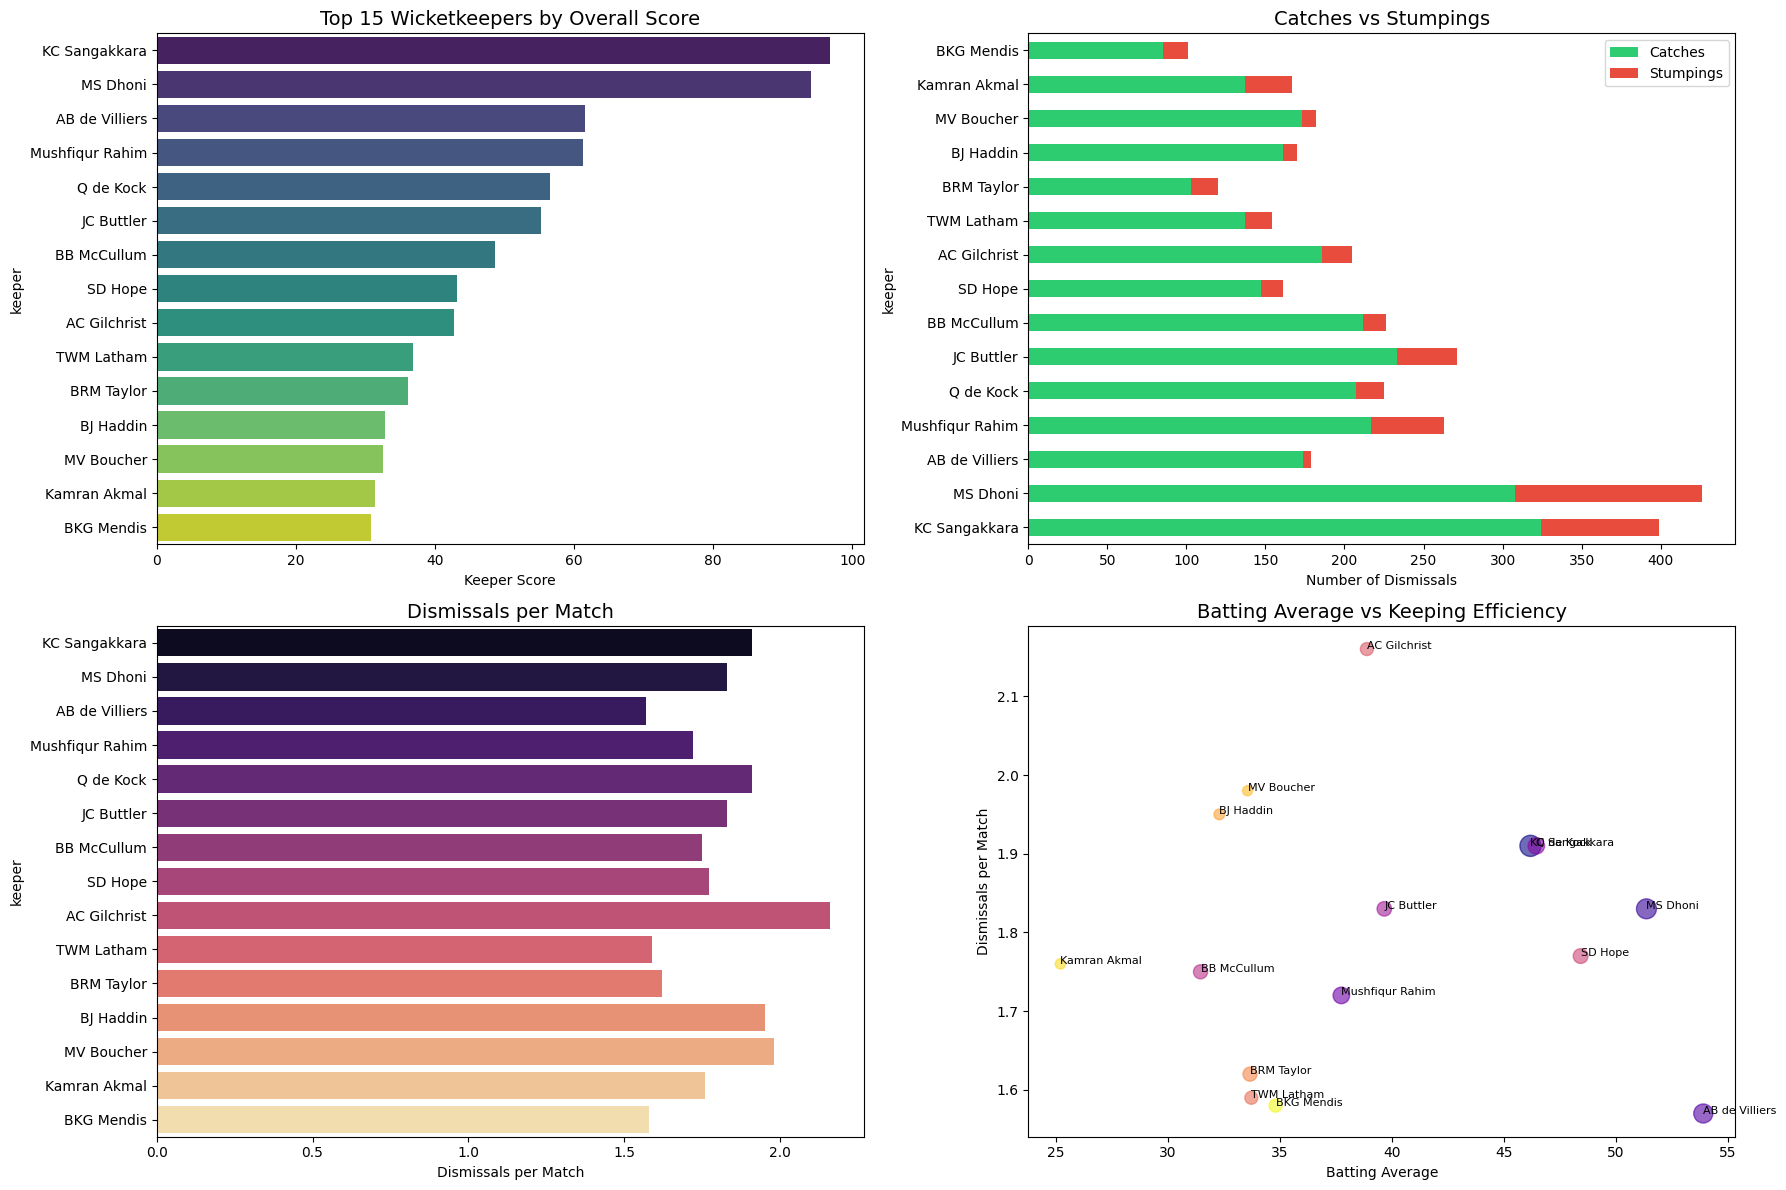

In [11]:
plt.figure(figsize=(16, 10))

# Top 15 keepers by score
top15 = final_keepers.head(15)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Top keepers by score
sns.barplot(data=top15, x='keeper_score', y='keeper', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Top 15 Wicketkeepers by Overall Score', fontsize=14)
axes[0,0].set_xlabel('Keeper Score')

# Plot 2: Dismissals breakdown (catches vs stumpings)
top15.set_index('keeper')[['catches', 'stumpings']].plot(
    kind='barh', stacked=True, ax=axes[0,1], color=['#2ecc71', '#e74c3c']
)
axes[0,1].set_title('Catches vs Stumpings', fontsize=14)
axes[0,1].set_xlabel('Number of Dismissals')
axes[0,1].legend(['Catches', 'Stumpings'])

# Plot 3: Dismissals per match
sns.barplot(data=top15, x='dismissals_per_match', y='keeper', ax=axes[1,0], palette='magma')
axes[1,0].set_title('Dismissals per Match', fontsize=14)
axes[1,0].set_xlabel('Dismissals per Match')

# Plot 4: Batting average vs dismissals
scatter = axes[1,1].scatter(
    top15['average'], 
    top15['dismissals_per_match'],
    s=top15['runs']/50,  # Size based on runs
    alpha=0.6,
    c=range(len(top15)),
    cmap='plasma'
)
axes[1,1].set_title('Batting Average vs Keeping Efficiency', fontsize=14)
axes[1,1].set_xlabel('Batting Average')
axes[1,1].set_ylabel('Dismissals per Match')

# Add labels for each point
for i, row in top15.iterrows():
    axes[1,1].annotate(row['keeper'], 
                       (row['average'], row['dismissals_per_match']),
                       fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
wicketkeepers.to_csv("../data/wicket_keeper_stats.csv",index = False)

In [24]:
df_keeper = pd.read_csv("E:\Data analysis projects\cricket_odi_analytics\data\wicket_keeper_stats.csv")

In [25]:
df_keeper.head()

,keeper,catches,stumpings,total_dismissals,matches_as_keeper,batter,team,matches,innings,dismisals,...,100s,highest_score,strike_rate,average,dismissals_per_match,catches_per_match,stumpings_per_match,runs_score,keeping_score,keeper_score
0,A Bagai,29,5,34,20,A Bagai,Canada,24,24,21,...,0,87,61.71,29.24,1.70,1.45,0.25,5.27,7.98,6.62
1,A Hunter,16,9,25,14,A Hunter,Ireland,39,39,36,...,1,121,83.58,31.39,1.79,1.14,0.64,9.71,5.87,7.79
2,A Saud,8,2,10,5,A Saud,Nepal,11,11,11,...,0,51,47.13,17.18,2.00,1.60,0.40,1.62,2.35,1.98
3,A Sharma,22,1,23,16,A Sharma,United Arab Emirates,29,29,27,...,0,98,73.07,21.41,1.44,1.38,0.06,4.97,5.40,5.18
4,A Valthapa,3,1,4,2,A Valthapa,United Arab Emirates,1,1,1,...,0,14,63.64,14.00,2.00,1.50,0.50,0.12,0.94,0.53
